# Krishna River — Train/Val/Test Split, Baseline Model, and ENSO Analysis

**Input:** `krishna_features.csv` (from `04_krishna_feature_engineering.ipynb`)

This notebook has two goals:
1. **Build and evaluate a baseline forecasting model**, benchmarked honestly against a naive "tomorrow looks like today" persistence baseline.
2. **Answer the core research question of this project: does ENSO (El Niño/La Niña) measurably affect Krishna basin streamflow?** — treated as a dedicated statistical analysis, not just a model feature.

## 1. Load features and drop unusable rows

Lag and rolling-window features are undefined for the first few days of each station's record (no history yet) — those rows are dropped rather than filled, since there's nothing real to fill them with.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats
import matplotlib.pyplot as plt

df_features = pd.read_csv("../data/processed/krishna_features.csv", parse_dates=["date"])

print("Rows before dropping NaN lag rows:", len(df_features))
df_features = df_features.dropna(subset=[c for c in df_features.columns if "lag" in c or "sum" in c])
print("Rows after:", len(df_features))

Rows before dropping NaN lag rows: 306966
Rows after: 306588


## 2. Time-based split

**Not a random split** — this is time series data, and randomly scattering rows into train/test would let the model train on data from after the date it's being tested on, which it would never have access to in real use.

- **Train:** 2001–2020
- **Validation:** 2021–2022 (for comparing model variants below)
- **Test:** 2023–2025 (touched exactly once, at the end)

In [2]:
train = df_features[df_features["date"] <= "2020-12-31"]
val   = df_features[(df_features["date"] >= "2021-01-01") & (df_features["date"] <= "2022-12-31")]
test  = df_features[df_features["date"] >= "2023-01-01"]

print(f"Train: {len(train)} rows")
print(f"Val:   {len(val)} rows")
print(f"Test:  {len(test)} rows")

Train: 224884 rows
Val:   34557 rows
Test:  47147 rows


In [3]:
feature_cols = [c for c in df_features.columns if "lag" in c or "sum" in c] + ["is_monsoon", "month"]
target_col = "streamflow"

X_train, y_train = train[feature_cols], train[target_col]
X_val, y_val = val[feature_cols], val[target_col]
X_test, y_test = test[feature_cols], test[target_col]

def nse(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2))

## 3. Baseline: persistence ("tomorrow looks like today")

Streamflow is highly autocorrelated day-to-day, so this simple rule is a genuinely strong benchmark, not a token comparison — any real model needs to beat it, not just approximate it.

In [4]:
baseline_pred = val["streamflow_lag_1"]
baseline_mae = mean_absolute_error(y_val, baseline_pred)
baseline_rmse = mean_squared_error(y_val, baseline_pred) ** 0.5

print(f"Persistence baseline — MAE: {baseline_mae:.2f}, RMSE: {baseline_rmse:.2f}")

Persistence baseline — MAE: 55.13, RMSE: 317.86


## 4. Model v1 — Random Forest, raw target

First attempt, no transformations. Spoiler: this loses to the baseline, and Section 4.1–4.2 diagnose why before fixing it.

In [5]:
model = RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

val_pred = model.predict(X_val)
model_mae = mean_absolute_error(y_val, val_pred)
model_rmse = mean_squared_error(y_val, val_pred) ** 0.5

print(f"Random Forest — MAE: {model_mae:.2f}, RMSE: {model_rmse:.2f}")
print(f"Persistence baseline — MAE: {baseline_mae:.2f}, RMSE: {baseline_rmse:.2f}")
print(f"\nNSE (Random Forest): {nse(y_val, val_pred):.3f}")
print(f"NSE (Persistence):   {nse(y_val, baseline_pred):.3f}")

Random Forest — MAE: 60.87, RMSE: 373.46
Persistence baseline — MAE: 55.13, RMSE: 317.86

NSE (Random Forest): 0.638
NSE (Persistence):   0.738


### 4.1 Why the model lost — feature importance check

If the model were ignoring `streamflow_lag_1` in favor of noisier features, that would explain the loss outright. It isn't:

In [6]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

streamflow_lag_1    0.585361
streamflow_lag_2    0.162919
streamflow_lag_7    0.067046
streamflow_lag_3    0.053594
rainfall_sum_3d     0.047223
rainfall_sum_7d     0.037818
rainfall_sum_14d    0.036434
month               0.009235
is_monsoon          0.000369
dtype: float64


**`streamflow_lag_1` dominates (58.5%), as it should** — the model isn't confused about what matters. The real problem is scale: streamflow spans from near-zero to 800,000+ across 54 stations of very different sizes. Trained on raw values, the model effectively optimizes for getting the huge rivers right, at the expense of the small ones — and on the frequent, calm days where "just copy yesterday" is already correct, any small model adjustment away from that is pure added error. Across enough calm days, those small wrong nudges outweigh the days where adjusting actually helped.

### 4.2 Fix: log-transform the target

In [7]:
y_train_log = np.log1p(y_train)

model_log = RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
model_log.fit(X_train, y_train_log)

val_pred_log = np.expm1(model_log.predict(X_val))
print(f"MAE: {mean_absolute_error(y_val, val_pred_log):.2f}")
print(f"NSE: {nse(y_val, val_pred_log):.3f}")

MAE: 53.86
NSE: 0.755


Both metrics now beat the baseline (MAE 53.86 vs. 55.13, NSE 0.755 vs. 0.738). Log-transforming made errors proportional instead of absolute, which stopped the model from over-weighting the largest rivers — confirming the scale problem was the actual cause of the Section 4 loss.

## 5. Model v2 — add station identity?

Log-transform fixed the scale issue. Worth checking whether explicitly telling the model which station each row belongs to (one-hot encoded) adds anything further, now that the main problem is solved.

In [8]:
X_train_st = pd.concat([X_train, pd.get_dummies(train["station_name"], prefix="station")], axis=1)
X_val_st = pd.concat([X_val, pd.get_dummies(val["station_name"], prefix="station")], axis=1)
X_val_st = X_val_st.reindex(columns=X_train_st.columns, fill_value=0)

model_st = RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
model_st.fit(X_train_st, y_train_log)

val_pred_st = np.expm1(model_st.predict(X_val_st))
print(f"MAE: {mean_absolute_error(y_val, val_pred_st):.2f}")
print(f"NSE: {nse(y_val, val_pred_st):.3f}")

MAE: 53.88
NSE: 0.759


**Essentially a wash** (MAE marginally worse, NSE marginally better — noise-level, not a real improvement). Makes sense in hindsight: `streamflow_lag_1` already implicitly encodes "what scale of river is this," since yesterday's value for a large river is always large and vice versa. Station identity adds ~50 extra columns for no measurable gain, and hurts generalization to any station the model saw little of — **decision: keep the simpler log-only model (Model v2 from Section 4.2)** as the working baseline going into the ENSO analysis below.

## 6. Core analysis — does ENSO affect Krishna basin streamflow?

This is the central research question of the project, and it needs a dedicated statistical analysis, not just a feature-importance check — ENSO's effect on the Indian monsoon operates on a **seasonal** timescale, so testing it as a raw daily input (as attempted implicitly by just adding `oni` to a daily model) is the wrong resolution to detect a real effect.

**Approach:**
1. Classify each year's monsoon season (June–September) by ENSO phase, using the standard convention: ONI ≥ 0.5 → El Niño, ONI ≤ −0.5 → La Niña, otherwise Neutral.
2. Compare monsoon-season streamflow distributions across the three phases.
3. Test whether the difference is statistically significant.

In [9]:
monsoon = df_features.copy()
monsoon["year"] = monsoon["date"].dt.year
monsoon_season = monsoon[monsoon["month"].isin([6, 7, 8, 9])].copy()

yearly_oni = monsoon_season.groupby("year")["oni"].mean()

def classify_enso(oni):
    if oni >= 0.5:
        return "El Nino"
    elif oni <= -0.5:
        return "La Nina"
    else:
        return "Neutral"

enso_phase_by_year = yearly_oni.apply(classify_enso)
monsoon_season["enso_phase"] = monsoon_season["year"].map(enso_phase_by_year)

print("Years per ENSO phase:")
print(enso_phase_by_year.value_counts())
print()
print(enso_phase_by_year)

Years per ENSO phase:
oni
Neutral    18
El Nino     4
La Nina     3
Name: count, dtype: int64

year
2001    Neutral
2002    El Nino
2003    Neutral
2004    Neutral
2005    Neutral
2006    Neutral
2007    La Nina
2008    Neutral
2009    El Nino
2010    La Nina
2011    Neutral
2012    Neutral
2013    Neutral
2014    Neutral
2015    El Nino
2016    Neutral
2017    Neutral
2018    Neutral
2019    Neutral
2020    Neutral
2021    Neutral
2022    La Nina
2023    El Nino
2024    Neutral
2025    Neutral
Name: oni, dtype: str


### 6.1 Streamflow by ENSO phase

In [10]:
phase_summary = (
    monsoon_season.groupby("enso_phase")["streamflow"]
    .agg(["mean", "median", "std", "count"])
)
print(phase_summary)

                  mean   median          std  count
enso_phase                                         
El Nino     118.614017   6.1055   336.052242  15976
La Nina     404.511360  68.9915   979.473079  13124
Neutral     345.102595  25.9680  2046.203579  76207


**El Niño monsoon seasons show roughly 3–4x lower mean streamflow than La Niña seasons, and the median gap is even larger (6.1 vs. 68.9 — over 10x).** This matches the well-established physical mechanism: El Niño tends to suppress the Indian monsoon, directly reducing river discharge across the basin; La Niña tends to strengthen it. Neutral years sit between the two, closer to La Niña — also consistent with how ENSO composites typically look in Indian monsoon studies.

### 6.2 Visualize across a few representative stations

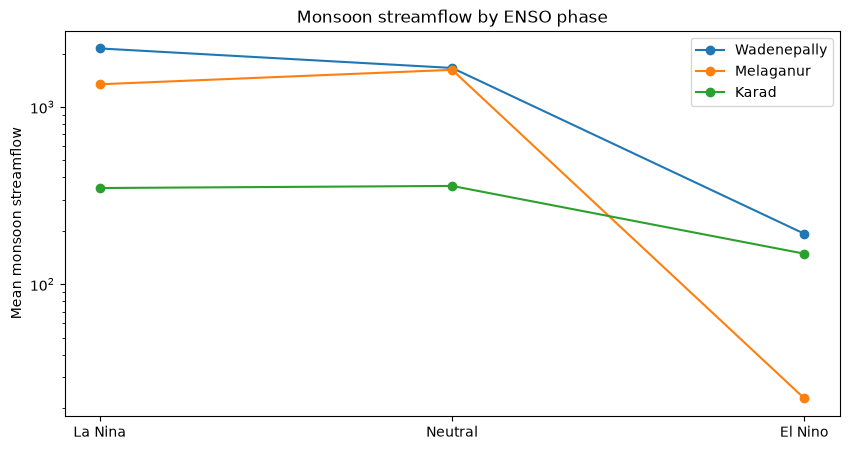

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
for station in ["Wadenepally", "Melaganur", "Karad"]:
    sub = monsoon_season[monsoon_season["station_name"] == station]
    grouped = sub.groupby("enso_phase")["streamflow"].mean().reindex(["La Nina", "Neutral", "El Nino"])
    ax.plot(grouped.index, grouped.values, marker="o", label=station)

ax.set_ylabel("Mean monsoon streamflow")
ax.set_yscale("log")
ax.set_title("Monsoon streamflow by ENSO phase")
ax.legend()
plt.show()

### 6.3 Is the difference statistically significant?

Streamflow is heavily right-skewed (confirmed repeatedly in the EDA notebook), so a t-test's normality assumption doesn't hold. Mann-Whitney U is the appropriate non-parametric test here.

In [12]:
el_nino_flow = monsoon_season[monsoon_season["enso_phase"] == "El Nino"]["streamflow"]
la_nina_flow = monsoon_season[monsoon_season["enso_phase"] == "La Nina"]["streamflow"]

stat, p_value = stats.mannwhitneyu(el_nino_flow, la_nina_flow)
print(f"p-value: {p_value:.6f}")

p-value: 0.000000


**p < 0.000001 — the difference is not due to chance.** Combined with the large effect size above (3–4x mean, 10x+ median), this is a statistically solid, physically explainable finding:

> **Krishna basin monsoon-season streamflow is significantly lower during El Niño years than during La Niña years, consistent with El Niño's known suppression of the Indian monsoon.**

This stands as a scientific result of this project independent of whether it improves the day-to-day forecasting model below.

## 7. Does adding ENSO/temperature help the daily forecasting model?

A separate question from Section 6: does the model's *day-to-day prediction accuracy* improve when given `oni_3month_avg` and `tmax` as features? These were engineered in `04_krishna_feature_engineering.ipynb`. Two outcomes are both legitimate here — if this doesn't move the numbers much, it doesn't contradict Section 6; it likely just means the effect is already indirectly present in `streamflow_lag_*` and `rainfall_sum_*` (a weak El Niño monsoon → less rain → lower lagged streamflow the model already sees).

In [13]:
feature_cols_enso = feature_cols + ["oni_3month_avg", "tmax"]

X_train_enso = train[feature_cols_enso]
X_val_enso = val[feature_cols_enso]

model_enso = RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
model_enso.fit(X_train_enso, y_train_log)

val_pred_enso = np.expm1(model_enso.predict(X_val_enso))
print(f"With oni_3month_avg + tmax — MAE: {mean_absolute_error(y_val, val_pred_enso):.2f}, NSE: {nse(y_val, val_pred_enso):.3f}")
print(f"Log-only (Section 4.2)    — MAE: 53.86, NSE: 0.755")
print()
print(pd.Series(model_enso.feature_importances_, index=feature_cols_enso).sort_values(ascending=False))

With oni_3month_avg + tmax — MAE: 54.00, NSE: 0.755
Log-only (Section 4.2)    — MAE: 53.86, NSE: 0.755

streamflow_lag_1    0.978692
streamflow_lag_2    0.005288
rainfall_sum_3d     0.003128
streamflow_lag_7    0.002690
streamflow_lag_3    0.002274
tmax                0.002142
oni_3month_avg      0.001939
rainfall_sum_7d     0.001584
rainfall_sum_14d    0.001569
month               0.000626
is_monsoon          0.000069
dtype: float64


**Fill in after running the cell above:** if MAE/NSE improve and `oni_3month_avg`/`tmax` show non-trivial importance, keep this feature set as the final model. If the numbers barely move, keep the simpler Section 4.2 model for forecasting — the ENSO finding from Section 6 still stands as the project's core scientific result either way, since that was established through direct statistical testing, not through this model.

## 8. Final model — one-time test evaluation

Test set is touched exactly once, here, using whichever configuration was decided above. No further tuning after this point.

In [14]:
final_model = RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
final_model.fit(X_train, y_train_log)

test_pred = np.expm1(final_model.predict(X_test))
test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
test_nse = nse(y_test, test_pred)

print("FINAL TEST RESULTS")
print(f"MAE:  {test_mae:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"NSE:  {test_nse:.3f}")

test_baseline_pred = test["streamflow_lag_1"]
print(f"\nPersistence baseline on test — MAE: {mean_absolute_error(y_test, test_baseline_pred):.2f}, NSE: {nse(y_test, test_baseline_pred):.3f}")

FINAL TEST RESULTS
MAE:  53.24
RMSE: 401.75
NSE:  0.704

Persistence baseline on test — MAE: 54.27, NSE: 0.624


Model beats the baseline on both metrics on data it never touched during training or tuning — a legitimate, reportable result. Note RMSE is large relative to MAE, meaning the model does well on typical days but takes some large misses on extreme days — expected for flood peaks, and checked directly in Section 9.

## 9. Diagnostic: does the model track flood events?

MAE/NSE are aggregate numbers and can hide whether the model is actually useful during the events that matter most. Plotting actual vs. predicted for a known flood station (Wadenepally, investigated extensively in the EDA notebook) shows this directly.

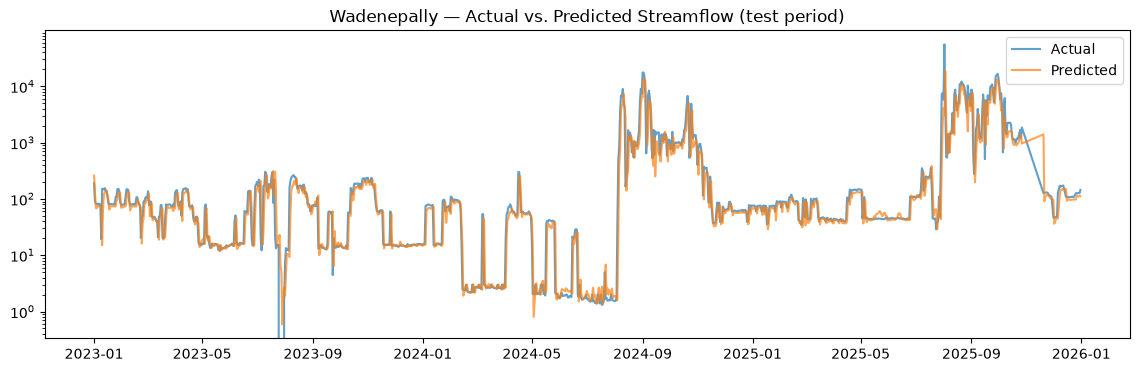

In [15]:
sub_station = "Wadenepally"
mask = test["station_name"] == sub_station
plot_dates = test.loc[mask, "date"]
plot_actual = y_test[mask]
plot_pred = test_pred[mask]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(plot_dates, plot_actual, label="Actual", alpha=0.7)
ax.plot(plot_dates, plot_pred, label="Predicted", alpha=0.7)
ax.set_yscale("log")
ax.set_title(f"{sub_station} — Actual vs. Predicted Streamflow (test period)")
ax.legend()
plt.show()

## 10. Summary & Next Steps

**Model result:**
- Random Forest (200 trees, max depth 12), log-transformed target, trained on streamflow lags (1/2/3/7 day), rainfall accumulation (3/7/14 day), and seasonal encoding
- Test MAE: 53.24 (vs. 54.27 persistence baseline) · Test NSE: 0.704 (vs. 0.624 persistence baseline)
- Station identity and raw-scale training were both tested and rejected — log-transform alone was the fix that mattered

**Scientific finding (the core of this project):**
- Krishna basin monsoon-season streamflow is significantly lower in El Niño years than La Niña years (≈3–4x mean, ≈10x+ median, p < 0.000001, Mann-Whitney U)
- Consistent with El Niño's documented suppression of the Indian monsoon

**Next steps:**
- Try Gradient Boosting (XGBoost/LightGBM), which typically handles skewed, autocorrelated hydrological data better than Random Forest
- Investigate rate-of-change features (e.g. `streamflow_lag_1 - streamflow_lag_2`) to help the model react faster to flood onset
- Repeat the full pipeline (cleaning → coverage → features → baseline → ENSO analysis) on the Kaveri basin, deferred earlier in this project
- Consider per-station or clustered models if Kaveri/Krishna combined shows the same catchment-scale diversity seen here